# 00 · Setup, data sampling, and zero-shot evaluation

This notebook is only a driver; all core logic lives in `vlm_opd/*.py` in the repository. It does three things:

1. Install the evaluation dependencies (vLLM) and read `HF_TOKEN` from Colab Secrets
2. Sample ChartQA with a fixed seed, resize images, and push to a private Hub dataset repo
3. Run a 500-sample zero-shot evaluation for the student (Qwen3-VL-2B) and the teacher (Qwen3-VL-8B) with vLLM, writing json to `outputs/`

> Before running, edit `REPO_URL` and `DATA_REPO` in the config cell below.
> Start with `SMOKE = True` (100 train / 50 test) to exercise the whole pipeline, then switch to `False` for the full run.

In [3]:
# ==================== Config ====================
REPO_URL  = "https://github.com/ffy208/On-Policy-Distillation-for-Vision-Language-Reasoning.git"
REPO_DIR  = "/content/vlm_opd_repo"
QUESTION_SOURCE = "human"   # "human" | "machine" | "all". Human-written ChartQA questions are much harder
                            # (random mix: 2B student 0.84 / 4B teacher 0.90 zero-shot on 50 rows, too little headroom).
DATA_REPO = f"ffyang/vlm_opd_chartqa_{QUESTION_SOURCE}"   # private Hub dataset repo, one per question source
RESULT_REPO = "ffyang/vlm_opd_results"  # optional: also push evaluation json to the Hub

SMOKE = False                 # True: 100/50 rows smoke test; False: 3000/500 full scale
N_TRAIN = 100 if SMOKE else 3000
N_TEST  = 50  if SMOKE else 500
SEED    = 42

import os
os.environ["HF_HOME"] = "/content/hf_cache"      # model cache on local disk, not Drive
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

## 1. Install dependencies

The evaluation environment installs only vLLM and its matching transformers version, not TRL / PEFT (the training notebook installs those separately).

In [2]:
# Install output is written to a log; only the tail is shown. Read the log if anything below fails to import.
!pip install -q -U "vllm>=0.8" "transformers>=4.57" "datasets>=3.0" "huggingface_hub>=0.26" qwen-vl-utils pillow pyyaml > /content/pip_install.log 2>&1; echo "pip exit code: $?"; tail -n 15 /content/pip_install.log

# vLLM upgrades torch (and torchvision) to a newer CUDA build, but Colab's preinstalled torchaudio stays on the
# old CUDA build. transformers imports torchaudio when loading any processor and torchaudio then fails its CUDA
# version check. We never use audio, so remove it instead of trying to match versions.
!pip uninstall -y -q torchaudio 2>/dev/null; echo "torchaudio removed"


pip exit code: 0
libraft-cu12 26.2.0 requires cuda-toolkit[cublas,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
numba-cuda 0.22.2 requires cuda-core<1.0.0,>=0.3.2, but you have cuda-core 1.0.1 which is incompatible.
cudf-cu12 26.2.1 requires cuda-python<13.0,>=12.9.2, but you have cuda-python 13.3.1 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.0 which is incompatible.
libcuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.3.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
pylibcudf-cu12 26.2.1 requires cuda-python<13.0,>=12.9.2, but you h

In [1]:
# Sanity check: these imports must succeed in the same interpreter that the evaluation subprocess will use.
import sys
print("python:", sys.executable, sys.version.split()[0])
import torch, transformers, vllm
from transformers import AutoProcessor  # pulls in processing_utils; this is where a stale torchaudio would fail
print("torch", torch.__version__, "(cuda", torch.version.cuda, ") | transformers", transformers.__version__, "| vllm", vllm.__version__)
print("cuda available:", torch.cuda.is_available())
GPU_NAME = torch.cuda.get_device_name(0)
GPU_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"GPU: {GPU_NAME} ({GPU_GB:.1f} GB)")
if GPU_GB < 30:
    print("WARNING: this is not a 40 GB A100. The 8B teacher does not fit; the notebook will fall back to the 4B teacher.")
    print("         For the real experiments switch to an A100 via Runtime > Change runtime type.")
if not torch.cuda.is_bf16_supported():
    print("WARNING: no bf16 support on this GPU; vLLM falls back to fp16 for evaluation.")

python: /usr/bin/python3 3.13.15
torch 2.13.0+cu130 (cuda 13.0 ) | transformers 5.16.1 | vllm 0.28.0
cuda available: True
GPU: NVIDIA A100-SXM4-40GB (39.5 GB)


In [4]:
!pip install -q --force-reinstall --no-deps pillow


## 2. Clone the repository and import `vlm_opd`

In [4]:
import os, sys
if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

import importlib, vlm_opd.common, vlm_opd.prepare, vlm_opd.evaluate, vlm_opd.hub_utils
for m in (vlm_opd.common, vlm_opd.prepare, vlm_opd.evaluate, vlm_opd.hub_utils):
    importlib.reload(m)   # re-run this cell after editing a .py file
from vlm_opd import common, prepare, evaluate, hub_utils
print("Prompt template preview:\n", common.build_prompt_text("What is the value for 2020?"))

Cloning into '/content/vlm_opd_repo'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 62 (delta 25), reused 58 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 34.74 KiB | 1.74 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Prompt template preview:
 Look at the chart and answer the question below.
Reason step by step: first read the relevant values from the chart, then do any calculation needed. Keep the reasoning concise.
On the last line, write the final answer in exactly this format:
Answer: <your answer>

Question: What is the value for 2020?


## 3. Read the HF token (stored in Colab Secrets as `HF_TOKEN`, never hard-coded)

In [5]:
from huggingface_hub import login
token = common.get_hf_token()
assert token, "Add HF_TOKEN to Colab Secrets and grant this notebook access"
login(token=token, add_to_git_credential=False)
print("HF login OK")

HF login OK


## 4. Sample the data and push to the Hub

Skip this cell if the data has already been pushed; load it from the Hub instead.

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…): reconstructing file:   0%|          |  0.00B /  219MB            

data/train-00000-of-00003-49492f364babfa(…): downloading bytes:           |  0.00B            

data/train-00001-of-00003-7302bae5e425bb(…): reconstructing file:   0%|          |  0.00B /  311MB            

data/train-00001-of-00003-7302bae5e425bb(…): downloading bytes:           |  0.00B            

...

Keeping human questions:   0%|          | 0/28299 [00:00<?, ? examples/s]

Processing train:   0%|          | 0/3000 [00:00<?, ? examples/s]

Keeping human questions:   0%|          | 0/2500 [00:00<?, ? examples/s]

Processing test:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'question', 'answer'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['id', 'image', 'question', 'answer'],
        num_rows: 500
    })
})
test_00000 (768, 535) | What is the average percentage share from 2013 to 2018 in offline sales of jewelry, watches, and accessories retail sector in Germany? -> 91.1


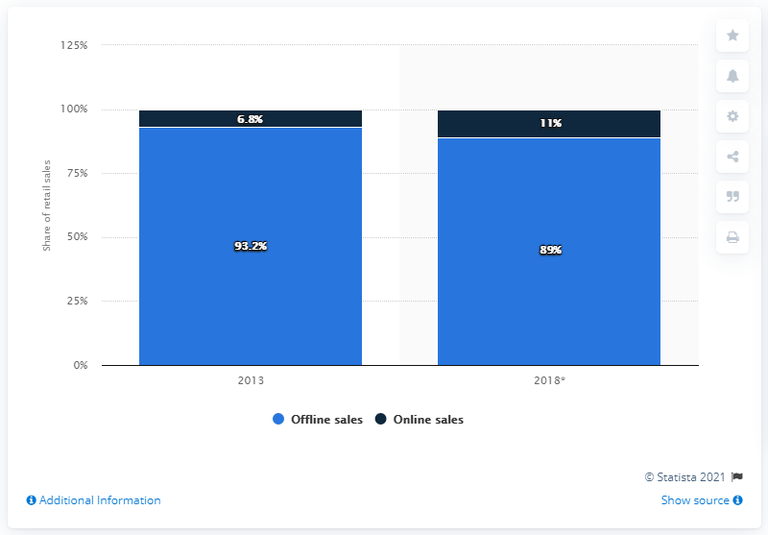

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmp_yrshozh.parquet    :   3%|3         | 1.09MB / 33.5MB            

In [6]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

ds = prepare.build_dataset(n_train=N_TRAIN, n_test=N_TEST, seed=SEED, token=token, question_source=QUESTION_SOURCE)
print(ds)
ex = ds["test"][0]
print(ex["id"], ex["image"].size, "|", ex["question"], "->", ex["answer"])
display(ex["image"])
prepare.push(ds, DATA_REPO, token=token)

In [7]:
# Load the test split back from the Hub to confirm it is readable
test_ds = common.load_hub_dataset(DATA_REPO, "test", token=token)
print(test_ds)

README.md:   0%|          | 0.00/482 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  192MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 33.5MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'image', 'question', 'answer'],
    num_rows: 500
})


## 5. Zero-shot evaluation

Each model is evaluated in its own subprocess (`python -m vlm_opd.evaluate`), so GPU memory is fully
released when the process exits. This avoids relying on vLLM engine cleanup inside the running kernel.
The subprocess reads the token from the `HF_TOKEN` environment variable.
The first download of the 8B teacher is about 16 GB and takes a few minutes.

In [8]:
import json, os, subprocess, sys
from pathlib import Path

OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
suffix = "_smoke" if SMOKE else ""
os.environ["HF_TOKEN"] = token   # only in this process's environment for the subprocess; never written to disk

def eval_in_subprocess(model_id: str, tag: str, gpu_mem: float = 0.85, limit: int | None = None) -> dict:
    """Run vlm_opd.evaluate in a child process, streaming its output and saving a full log.

    On failure the last lines of the log are printed so the real error is visible here,
    instead of only the CalledProcessError from the wrapper.
    """
    out = OUT_DIR / f"eval_{tag}{suffix}.json"
    log_path = OUT_DIR / f"eval_{tag}{suffix}.log"
    cmd = [sys.executable, "-m", "vlm_opd.evaluate",
           "--model", model_id, "--data-repo", DATA_REPO, "--split", "test",
           "--out", str(out), "--tag", tag, "--seed", str(SEED), "--gpu-mem", str(gpu_mem)]
    if limit:
        cmd += ["--limit", str(limit)]
    print("$", " ".join(cmd))
    with log_path.open("w") as log:
        proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in proc.stdout:
            log.write(line)
            sys.stdout.write(line)
        rc = proc.wait()
    if rc != 0:
        tail = "".join(log_path.read_text().splitlines(keepends=True)[-40:])
        raise RuntimeError(f"evaluation subprocess failed (exit {rc}); full log: {log_path}\n--- log tail ---\n{tail}")
    res = json.loads(out.read_text())
    print(f"[{tag}] acc = {res['accuracy']:.4f}  format = {res['format_rate']:.4f}  n = {res['n']}  ({res['elapsed_sec']}s)")
    return res

In [9]:
# 5a. Student zero-shot (baseline 0)
student_res = eval_in_subprocess(common.STUDENT_MODEL, "student_zeroshot")
print(student_res["records"][0]["output"][:600])

$ /usr/bin/python3 -m vlm_opd.evaluate --model Qwen/Qwen3-VL-2B-Instruct --data-repo ffyang/vlm_opd_chartqa_human --split test --out outputs/eval_student_zeroshot.json --tag student_zeroshot --seed 42 --gpu-mem 0.85
2026-09-07 22:42:14,433 INFO NumExpr defaulting to 12 threads.
2026-09-07 22:42:14,901 INFO TensorFlow version 2.20.0 available.
2026-09-07 22:42:14,902 INFO JAX version 0.11.1 available.
2026-09-07 22:42:15,541 INFO Loading dataset ffyang/vlm_opd_chartqa_human [test] from the Hub
2026-09-07 22:42:15,662 INFO HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-09-07 22:42:15,874 INFO HTTP Request: HEAD https://huggingface.co/datasets/ffyang/vlm_opd_chartqa_human/resolve/main/README.md "HTTP/1.1 200 OK"
2026-09-07 22:42:15,970 INFO HTTP Request: GET https://huggingface.co/datasets/ffyang/vlm_opd_chartqa_human/resolve/main/README.md "HTTP/1.1 200 OK"
2026-09-07 22:42:16,054 INFO HTTP Request: HEAD https://huggingface.co/datasets/ffyang/vlm_opd_

In [10]:
# 5b. Teacher zero-shot (teacher upper bound).
# The 8B teacher needs ~16 GB of weights alone, so on GPUs under 30 GB (e.g. a 15 GB T4) fall back to the 4B teacher.
TEACHER_FOR_THIS_GPU = common.TEACHER_MODEL if GPU_GB >= 30 else common.TEACHER_MODEL_SMALL
print("teacher:", TEACHER_FOR_THIS_GPU)
teacher_res = eval_in_subprocess(TEACHER_FOR_THIS_GPU, "teacher_zeroshot", gpu_mem=0.9)
print(teacher_res["records"][0]["output"][:600])

teacher: Qwen/Qwen3-VL-8B-Instruct
$ /usr/bin/python3 -m vlm_opd.evaluate --model Qwen/Qwen3-VL-8B-Instruct --data-repo ffyang/vlm_opd_chartqa_human --split test --out outputs/eval_teacher_zeroshot.json --tag teacher_zeroshot --seed 42 --gpu-mem 0.9
2026-09-07 22:46:37,493 INFO NumExpr defaulting to 12 threads.
2026-09-07 22:46:37,954 INFO TensorFlow version 2.20.0 available.
2026-09-07 22:46:37,954 INFO JAX version 0.11.1 available.
2026-09-07 22:46:38,599 INFO Loading dataset ffyang/vlm_opd_chartqa_human [test] from the Hub
2026-09-07 22:46:38,807 INFO HTTP Request: HEAD https://huggingface.co/datasets/ffyang/vlm_opd_chartqa_human/resolve/main/README.md "HTTP/1.1 200 OK"
2026-09-07 22:46:38,883 INFO HTTP Request: HEAD https://huggingface.co/datasets/ffyang/vlm_opd_chartqa_human/resolve/e744081a9f45f205f2bb89325bd09f378cf76c7f/vlm_opd_chartqa_human.py "HTTP/1.1 404 Not Found"
2026-09-07 22:46:39,032 INFO HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/data

## 6. Summarize and save

If teacher zero-shot accuracy is below 60%, switch to Geometry3K as described in the project plan.

In [11]:
import json
summary = {
    "n_test": len(test_ds),
    "seed": SEED,
    "question_source": QUESTION_SOURCE,
    "data_repo": DATA_REPO,
    "gpu": GPU_NAME,
    "student_model": common.STUDENT_MODEL,
    "teacher_model": TEACHER_FOR_THIS_GPU,
    "student_zeroshot": student_res["accuracy"],
    "teacher_zeroshot": teacher_res["accuracy"],
    "student_format_rate": student_res["format_rate"],
    "teacher_format_rate": teacher_res["format_rate"],
}
print(json.dumps(summary, indent=2))
(OUT_DIR / f"summary_stage0{suffix}.json").write_text(json.dumps(summary, indent=2))
if summary["teacher_zeroshot"] < 0.60:
    print("WARNING: teacher zero-shot accuracy is below 60%; consider switching to Geometry3K")

{
  "n_test": 500,
  "seed": 42,
  "question_source": "human",
  "data_repo": "ffyang/vlm_opd_chartqa_human",
  "gpu": "NVIDIA A100-SXM4-40GB",
  "student_model": "Qwen/Qwen3-VL-2B-Instruct",
  "teacher_model": "Qwen/Qwen3-VL-8B-Instruct",
  "student_zeroshot": 0.668,
  "teacher_zeroshot": 0.844,
  "student_format_rate": 0.96,
  "teacher_format_rate": 0.992
}


In [12]:
# Optional: push the evaluation json to a private Hub repo so it survives a session disconnect
for name in (f"eval_student_zeroshot{suffix}.json", f"eval_teacher_zeroshot{suffix}.json", f"summary_stage0{suffix}.json"):
    hub_utils.upload_small_file(OUT_DIR / name, RESULT_REPO, token=token)
print("Results pushed to", RESULT_REPO)

Results pushed to ffyang/vlm_opd_results
